In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 
%matplotlib inline

In [5]:
df = pd.read_csv("C:/Users/USUARIO/Documents/Codigos/Análisis de datos con Python/resources/laptop_pricing_dataset_mod2.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


In [6]:
lm = LinearRegression()
lm

LinearRegression()

In [9]:
X = df[['CPU_frequency']]
Y = df['Price']
lm.fit(X,Y)

LinearRegression()

In [13]:
Yhat=lm.predict(X)
Yhat[0:5]   

array([1073.07834392, 1277.93263722, 1636.42765051, 1073.07834392,
       1175.50549057])

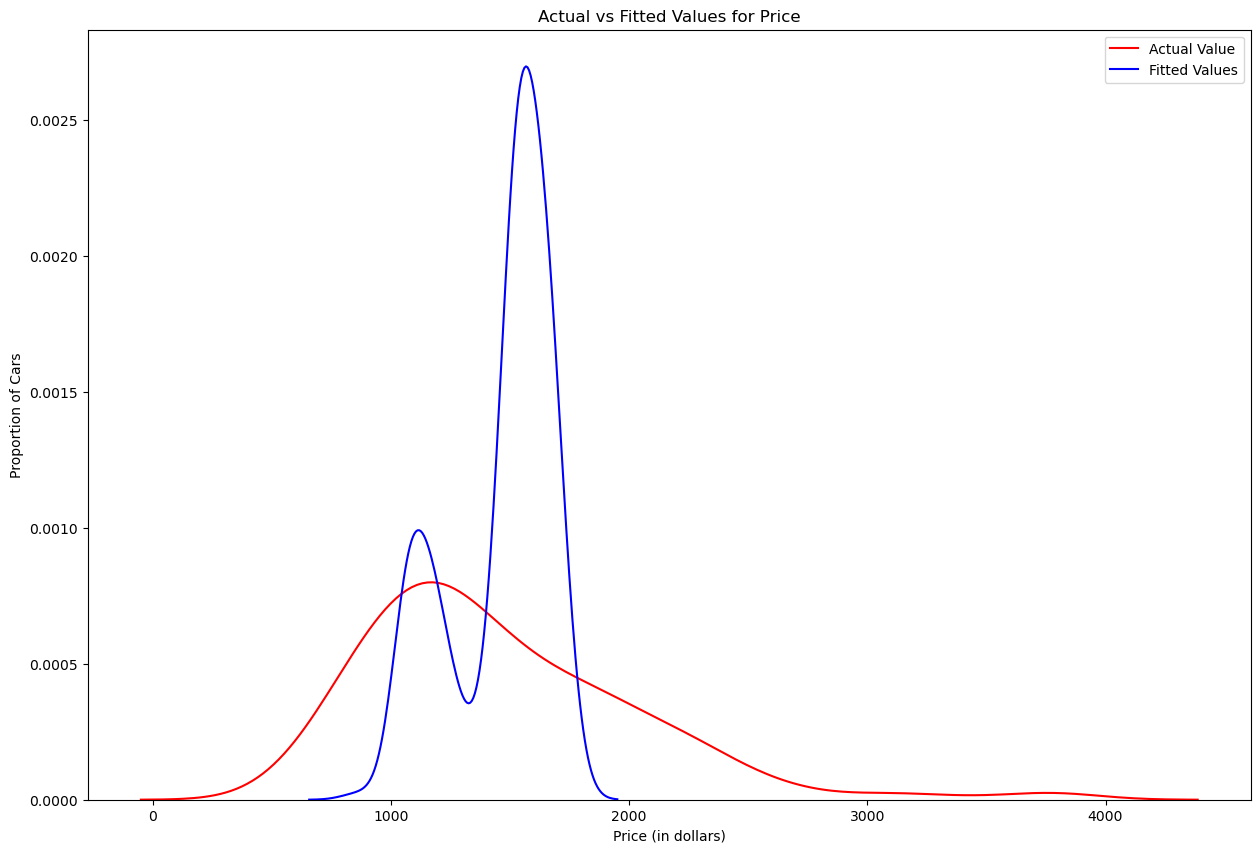

In [18]:
plt.figure(figsize=(width, height))

ax1 = sns.kdeplot(df['Price'], color="r", label="Actual Value")
sns.kdeplot(Yhat, color="b", label="Fitted Values", ax=ax1)

ax1.set_xlabel("Price")
ax1.set_ylabel("Density")
ax1.legend()

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()


In [21]:
print('The R-square is: ', lm.score(X, Y))

mse = mean_squared_error(df['Price'], Yhat)
print('The mean square error of price and predicted value is: ', mse)

The R-square is:  0.1344436321024326
The mean square error of price and predicted value is:  284583.4405868629


In [24]:

lm1 = LinearRegression()
Z = df[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']]
lm1.fit(Z,Y)
Y_hat = lm1.predict(Z)
Y_hat[0:5]



array([1345.51622771,  710.44905496, 1552.37242687, 1295.00681012,
       1543.13847022])

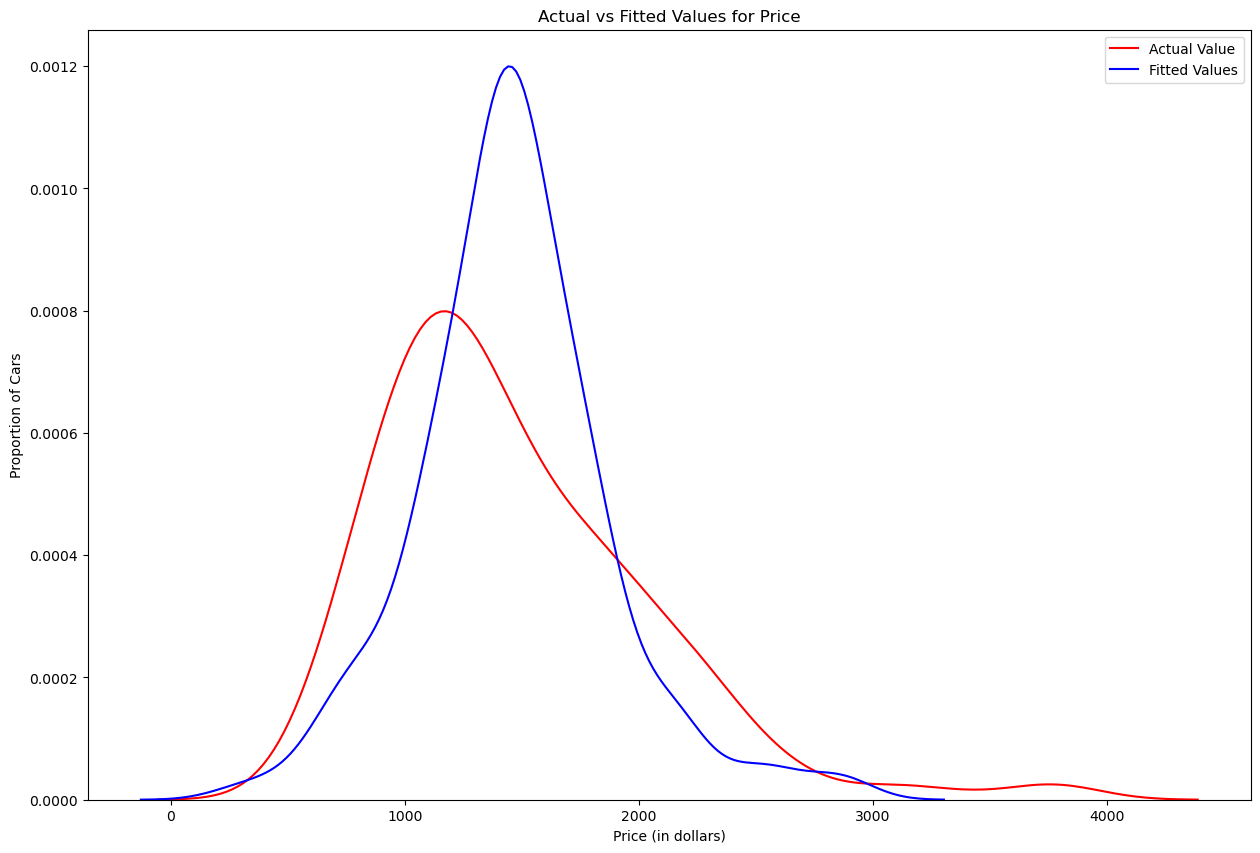

In [25]:
plt.figure(figsize=(width, height))

ax1 = sns.kdeplot(df['Price'], color="r", label="Actual Value")
sns.kdeplot(Y_hat, color="b", label="Fitted Values", ax=ax1)

ax1.set_xlabel("Price")
ax1.set_ylabel("Density")
ax1.legend()

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

In [30]:
print('The R-square is: ', lm1.score(X, Y))

# mse1 = mean_squared_error(df['Price'], Y_hat)
# print('The mean square error of price and predicted value is: ', mse1)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- CPU_core
- Category
- GPU
- OS
- RAM_GB
- ...


In [51]:
# Here we use a polynomial of the 3rd order (cubic) 
X = df['CPU_frequency']
Y = df['Price']


f = np.polyfit(X, Y, 3)
p = np.poly1d(f)
print(p)

           3             2
3.409e+04 x - 6.574e+04 x + 4.129e+04 x - 7238


In [43]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Portatil')

    plt.show()
    plt.close()



In [52]:
X = X.to_numpy().flatten()

f1 = np.polyfit(X, Y, 1)
p1 = np.poly1d(f1)

f3 = np.polyfit(X, Y, 3)
p3 = np.poly1d(f3)

f5 = np.polyfit(X, Y, 5)
p5 = np.poly1d(f5)



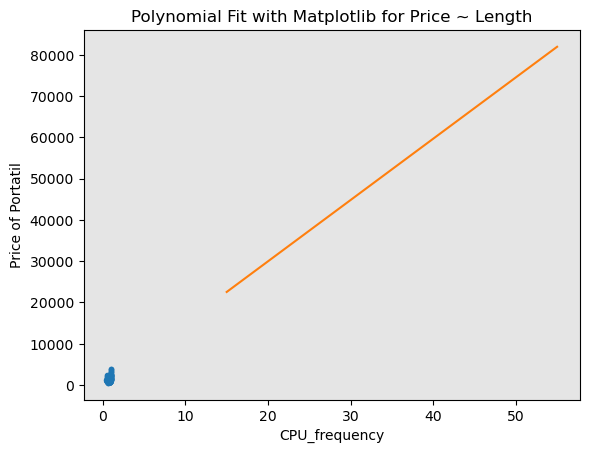

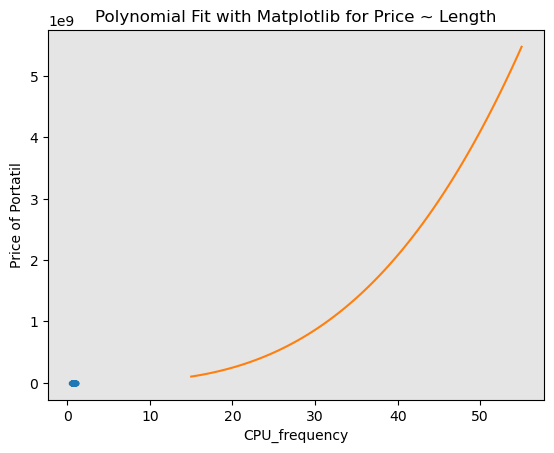

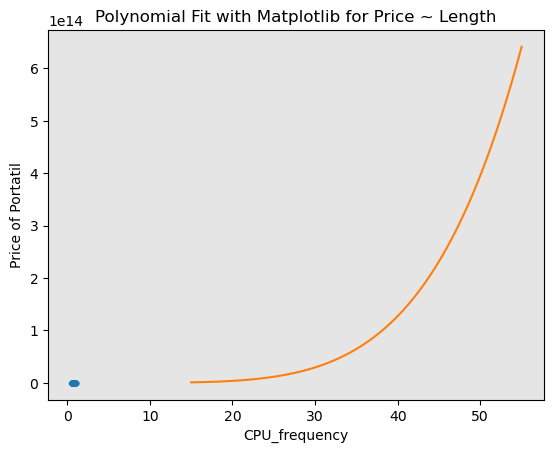

In [59]:
PlotPolly(p1, x, y, 'CPU_frequency')
PlotPolly(p3, x, y, 'CPU_frequency')
PlotPolly(p5, x, y, 'CPU_frequency')

In [60]:

r_squared_1 = r2_score(Y, p1(X))
print('The R-square value for 1st degree polynomial is: ', r_squared_1)
print('The MSE value for 1st degree polynomial is: ', mean_squared_error(Y,p1(X)))
r_squared_3 = r2_score(Y, p3(X))
print('The R-square value for 3rd degree polynomial is: ', r_squared_3)
print('The MSE value for 3rd degree polynomial is: ', mean_squared_error(Y,p3(X)))
r_squared_5 = r2_score(Y, p5(X))
print('The R-square value for 5th degree polynomial is: ', r_squared_5)
print('The MSE value for 5th degree polynomial is: ', mean_squared_error(Y,p5(X)))



The R-square value for 1st degree polynomial is:  0.1344436321024326
The MSE value for 1st degree polynomial is:  284583.4405868629
The R-square value for 3rd degree polynomial is:  0.26692640796530964
The MSE value for 3rd degree polynomial is:  241024.86303848817
The R-square value for 5th degree polynomial is:  0.3030822706443487
The MSE value for 5th degree polynomial is:  229137.29548054867


In [62]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]

pipe=Pipeline(Input)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [63]:
Z = Z.astype(float)
pipe.fit(Z,y)


ypipe=pipe.predict(Z)
ypipe[0:4]

array([1484.1796875 ,  778.55078125, 1267.99609375, 1009.30078125])

In [65]:

print('MSE for multi-variable polynomial pipeline is: ', mean_squared_error(Y, ypipe))
print('R^2 for multi-variable polynomial pipeline is: ', r2_score(Y, ypipe))


MSE for multi-variable polynomial pipeline is:  120596.17626203009
R^2 for multi-variable polynomial pipeline is:  0.633208495573596
